## Hypothesis 4
Averaging the predicted class probabilities from independently trained models will improve validation performance compared with using a single model. Although the three models use the same architecture, hyperparameters, and training data, different initialization and minibatch-shuffling seeds can cause them to learn slightly different decision boundaries and make different errors. Averaging their probability distributions should reduce seed-specific errors and produce more reliable predictions. I therefore expect two-model ensembles to achieve higher mean validation accuracy and lower mean cross-entropy loss than their constituent individual models, while the full three-model ensemble is expected to provide the strongest or most stable overall performance.

In [5]:
from pathlib import Path
from itertools import combinations
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from matplotlib.ticker import PercentFormatter

import scratch

importlib.reload(scratch)

from scratch import *

In [6]:
print("Loading MNIST data...")

train_dataset, test_dataset = load_mnist_data()

print("Preprocessing MNIST data...")

(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
) = preprocess_data(
    train_dataset,
    test_dataset,
    train_size=50000,
    test_size=10000,
    SPLIT_SEED=SPLIT_SEED
)


print("\nData shapes")
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


assert X_train.shape == (50000, 784)
assert X_val.shape == (10000, 784)
assert X_test.shape == (10000, 784)

Loading MNIST data...
Preprocessing MNIST data...
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Original test images: (10000, 28, 28)
Original test labels: (10000,)
Splitting the training data into training and validation sets...
Training images: (50000, 28, 28)
Training labels: (50000,)
Validation images: (10000, 28, 28)
Validation labels: (10000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Before Normalization:
Training data range: 0.0 to 255.0
Validation data range: 0.0 to 255.0
Test data range: 0.0 to 255.0
Performing normalization of the data...
After Normalization:
Training data range: 0.0 to 1.0
Validation data range: 0.0 to 1.0
Test data range: 0.0 to 1.0

Data shapes
Training: (50000, 784) (50000,)
Validation: (10000, 784) (10000,)
Test: (10000, 784) (10000,)


In [7]:
OH4_OUTPUT_DIR = Path(
    "output/hypotheses/h4_seed_ensemble"
)

OH4_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


OH4_MODEL_DIR = Path(
    "output/test_reports/checkpoints"
)


OH4_SEEDS = generate_experiment_seeds(
    base_seed=SPLIT_SEED,
    number_of_seeds=3
)


OH4_EVALUATION_BATCH_SIZE = 1000


print("H4 output folder:", OH4_OUTPUT_DIR)
print("Saved-model folder:", OH4_MODEL_DIR)
print("Seeds:", OH4_SEEDS)

H4 output folder: output/hypotheses/h4_seed_ensemble
Saved-model folder: output/test_reports/checkpoints
Seeds: [654571, 89250, 773955]


In [8]:
oh4_models = {}
oh4_checkpoint_rows = []
intialization = "small" 
learning_rate = "0p1"

for seed in OH4_SEEDS:

    # checkpoint_path = (
    #     OH4_MODEL_DIR
    #     / f"best_model_seed_{seed}.pt"
    # )
    checkpoint_path = (
            OH4_MODEL_DIR
            / f"best_model_init-{intialization}_lr-{learning_rate}_seed-{seed}.pt"
        )

    assert checkpoint_path.exists(), (
        f"Checkpoint not found: "
        f"{checkpoint_path}"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True
    )

    parameters = {
        parameter_name: (
            parameter_tensor
            .cpu()
            .numpy()
            .copy()
        )
        for (
            parameter_name,
            parameter_tensor
        ) in checkpoint[
            "parameters"
        ].items()
    }

   

    oh4_models[seed] = {
        "parameters": parameters,
        "activation": checkpoint[
            "activation"
        ],
        "selected_epoch": checkpoint[
            "best_epoch"
        ]
    }

    oh4_checkpoint_rows.append({
        "seed": seed,
        "selected_epoch": checkpoint[
            "best_epoch"
        ],
        "validation_accuracy": checkpoint[
            "best_val_accuracy"
        ],
        "validation_loss": checkpoint[
            "best_val_loss"
        ],
        "checkpoint_path": str(
            checkpoint_path
        )
    })


oh4_checkpoint_df = pd.DataFrame(
    oh4_checkpoint_rows
)

display(oh4_checkpoint_df)

,seed,selected_epoch,validation_accuracy,validation_loss,checkpoint_path
0,654571,75,0.9800,0.072569,output/test_reports/checkpoints/best_model_ini...
1,89250,68,0.9795,0.075936,output/test_reports/checkpoints/best_model_ini...
2,773955,80,0.9789,0.074269,output/test_reports/checkpoints/best_model_ini...


In [9]:
def oh4_predict_probabilities(
    X,
    parameters,
    activation,
    batch_size=1000
):
    probability_batches = []

    for start in range(
        0,
        X.shape[0],
        batch_size
    ):
        end = min(
            start + batch_size,
            X.shape[0]
        )

        X_batch = X[start:end]

        probabilities, _ = forward_pass(
            X_batch,
            parameters,
            activation
        )

        probability_batches.append(
            probabilities
        )

    return np.vstack(
        probability_batches
    )


def oh4_metrics_from_probabilities(
    probabilities,
    y
):
    predictions = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = np.mean(
        predictions == y
    )

    correct_class_probabilities = (
        probabilities[
            np.arange(y.shape[0]),
            y
        ]
    )

    # Avoid log(0) if a probability is extremely small.
    safe_probabilities = np.clip(
        correct_class_probabilities,
        1e-15,
        1.0
    )

    cross_entropy_loss = -np.mean(
        np.log(safe_probabilities)
    )

    return {
        "loss": cross_entropy_loss,
        "accuracy": accuracy,
        "predictions": predictions
    }

In [10]:
oh4_individual_probabilities = {}
oh4_individual_metrics = {}
oh4_result_rows = []


for seed in OH4_SEEDS:

    model_information = oh4_models[
        seed
    ]

    probabilities = (
        oh4_predict_probabilities(
            X=X_val,
            parameters=model_information[
                "parameters"
            ],
            activation=model_information[
                "activation"
            ],
            batch_size=(
                OH4_EVALUATION_BATCH_SIZE
            )
        )
    )

    assert probabilities.shape == (
        X_val.shape[0],
        10
    )

    assert np.allclose(
        probabilities.sum(axis=1),
        1.0
    )

    metrics = (
        oh4_metrics_from_probabilities(
            probabilities,
            y_val
        )
    )

    oh4_individual_probabilities[
        seed
    ] = probabilities

    oh4_individual_metrics[
        seed
    ] = metrics

    oh4_result_rows.append({
        "model_type": "individual",
        "model_name": str(seed),
        "ensemble_size": 1,
        "members": str(seed),
        "loss": metrics["loss"],
        "accuracy": metrics["accuracy"]
    })

    print(
        f"Individual seed {seed} | "
        f"loss={metrics['loss']:.4f} | "
        f"accuracy="
        f"{100 * metrics['accuracy']:.2f}%"
    )

Individual seed 654571 | loss=0.0726 | accuracy=98.00%
Individual seed 89250 | loss=0.0759 | accuracy=97.95%
Individual seed 773955 | loss=0.0743 | accuracy=97.89%


In [11]:
oh4_pair_rows = []
oh4_pair_probabilities = {}
oh4_pair_metrics = {}


for seed_a, seed_b in combinations(
    OH4_SEEDS,
    2
):
    pair_name = (
        f"{seed_a} + {seed_b}"
    )

    pair_probabilities = (
        oh4_individual_probabilities[
            seed_a
        ]
        + oh4_individual_probabilities[
            seed_b
        ]
    ) / 2.0

    pair_metrics = (
        oh4_metrics_from_probabilities(
            pair_probabilities,
            y_val
        )
    )

    constituent_accuracy_mean = np.mean([
        oh4_individual_metrics[
            seed_a
        ]["accuracy"],
        oh4_individual_metrics[
            seed_b
        ]["accuracy"]
    ])

    constituent_loss_mean = np.mean([
        oh4_individual_metrics[
            seed_a
        ]["loss"],
        oh4_individual_metrics[
            seed_b
        ]["loss"]
    ])

    accuracy_improvement = (
        pair_metrics["accuracy"]
        - constituent_accuracy_mean
    )

    loss_reduction = (
        constituent_loss_mean
        - pair_metrics["loss"]
    )

    oh4_pair_probabilities[
        pair_name
    ] = pair_probabilities

    oh4_pair_metrics[
        pair_name
    ] = pair_metrics

    pair_row = {
        "model_type": "two_model_ensemble",
        "model_name": pair_name,
        "ensemble_size": 2,
        "members": pair_name,
        "loss": pair_metrics["loss"],
        "accuracy": pair_metrics[
            "accuracy"
        ],
        "constituent_accuracy_mean": (
            constituent_accuracy_mean
        ),
        "constituent_loss_mean": (
            constituent_loss_mean
        ),
        "accuracy_improvement": (
            accuracy_improvement
        ),
        "loss_reduction": loss_reduction
    }

    oh4_pair_rows.append(
        pair_row
    )

    oh4_result_rows.append(
        pair_row
    )

    print(
        f"Pair ensemble {pair_name} | "
        f"loss={pair_metrics['loss']:.4f} | "
        f"accuracy="
        f"{100 * pair_metrics['accuracy']:.2f}% | "
        f"accuracy change="
        f"{100 * accuracy_improvement:+.2f} "
        "points | "
        f"loss reduction="
        f"{loss_reduction:+.4f}"
    )

Pair ensemble 654571 + 89250 | loss=0.0676 | accuracy=97.97% | accuracy change=-0.00 points | loss reduction=+0.0067
Pair ensemble 654571 + 773955 | loss=0.0665 | accuracy=97.98% | accuracy change=+0.04 points | loss reduction=+0.0070
Pair ensemble 89250 + 773955 | loss=0.0679 | accuracy=97.94% | accuracy change=+0.02 points | loss reduction=+0.0072


In [12]:
oh4_full_probabilities = np.mean(
    np.stack([
        oh4_individual_probabilities[
            seed
        ]
        for seed in OH4_SEEDS
    ]),
    axis=0
)


oh4_full_metrics = (
    oh4_metrics_from_probabilities(
        oh4_full_probabilities,
        y_val
    )
)


individual_accuracy_values = np.array([
    oh4_individual_metrics[
        seed
    ]["accuracy"]
    for seed in OH4_SEEDS
])

individual_loss_values = np.array([
    oh4_individual_metrics[
        seed
    ]["loss"]
    for seed in OH4_SEEDS
])


oh4_full_accuracy_improvement = (
    oh4_full_metrics["accuracy"]
    - individual_accuracy_values.mean()
)

oh4_full_loss_reduction = (
    individual_loss_values.mean()
    - oh4_full_metrics["loss"]
)

oh4_full_change_from_best_individual = (
    oh4_full_metrics["accuracy"]
    - individual_accuracy_values.max()
)


oh4_result_rows.append({
    "model_type": "three_model_ensemble",
    "model_name": "All three seeds",
    "ensemble_size": 3,
    "members": ", ".join(
        map(str, OH4_SEEDS)
    ),
    "loss": oh4_full_metrics["loss"],
    "accuracy": oh4_full_metrics[
        "accuracy"
    ],
    "constituent_accuracy_mean": (
        individual_accuracy_values.mean()
    ),
    "constituent_loss_mean": (
        individual_loss_values.mean()
    ),
    "accuracy_improvement": (
        oh4_full_accuracy_improvement
    ),
    "loss_reduction": (
        oh4_full_loss_reduction
    )
})


print(
    "Full three-model ensemble | "
    f"loss={oh4_full_metrics['loss']:.4f} | "
    f"accuracy="
    f"{100 * oh4_full_metrics['accuracy']:.2f}%"
)

print(
    "Accuracy change from mean individual:",
    f"{100 * oh4_full_accuracy_improvement:+.2f} "
    "percentage points"
)

print(
    "Accuracy change from best individual:",
    f"{100 * oh4_full_change_from_best_individual:+.2f} "
    "percentage points"
)

print(
    "Loss reduction from mean individual:",
    f"{oh4_full_loss_reduction:+.4f}"
)

Full three-model ensemble | loss=0.0650 | accuracy=98.00%
Accuracy change from mean individual: +0.05 percentage points
Accuracy change from best individual: +0.00 percentage points
Loss reduction from mean individual: +0.0092


In [13]:
oh4_results_df = pd.DataFrame(
    oh4_result_rows
)


oh4_results_display_df = pd.DataFrame({
    "Model Type": oh4_results_df[
        "model_type"
    ].replace({
        "individual": "Individual",
        "two_model_ensemble": (
            "Two-Model Ensemble"
        ),
        "three_model_ensemble": (
            "Three-Model Ensemble"
        )
    }),
    "Model": oh4_results_df[
        "model_name"
    ],
    "Validation Loss": oh4_results_df[
        "loss"
    ].map(
        lambda value: f"{value:.4f}"
    ),
    "Validation Accuracy": oh4_results_df[
        "accuracy"
    ].map(
        lambda value: f"{100 * value:.2f}%"
    )
})


print("H4 individual and ensemble results")

display(oh4_results_display_df)

H4 individual and ensemble results


,Model Type,Model,Validation Loss,Validation Accuracy
0,Individual,654571,0.0726,98.00%
1,Individual,89250,0.0759,97.95%
2,Individual,773955,0.0743,97.89%
3,Two-Model Ensemble,654571 + 89250,0.0676,97.97%
4,Two-Model Ensemble,654571 + 773955,0.0665,97.98%
5,Two-Model Ensemble,89250 + 773955,0.0679,97.94%
6,Three-Model Ensemble,All three seeds,0.0650,98.00%


In [14]:
oh4_individual_df = (
    oh4_results_df[
        oh4_results_df[
            "model_type"
        ] == "individual"
    ]
)

oh4_pairs_df = (
    oh4_results_df[
        oh4_results_df[
            "model_type"
        ] == "two_model_ensemble"
    ]
)

oh4_full_df = (
    oh4_results_df[
        oh4_results_df[
            "model_type"
        ] == "three_model_ensemble"
    ]
)


oh4_comparison_rows = [
    {
        "condition": "Individual Models",
        "number_of_results": 3,
        "accuracy_mean": (
            oh4_individual_df[
                "accuracy"
            ].mean()
        ),
        "accuracy_std": (
            oh4_individual_df[
                "accuracy"
            ].std(ddof=1)
        ),
        "loss_mean": (
            oh4_individual_df[
                "loss"
            ].mean()
        ),
        "loss_std": (
            oh4_individual_df[
                "loss"
            ].std(ddof=1)
        )
    },
    {
        "condition": "Two-Model Ensembles",
        "number_of_results": 3,
        "accuracy_mean": (
            oh4_pairs_df[
                "accuracy"
            ].mean()
        ),
        "accuracy_std": (
            oh4_pairs_df[
                "accuracy"
            ].std(ddof=1)
        ),
        "loss_mean": (
            oh4_pairs_df[
                "loss"
            ].mean()
        ),
        "loss_std": (
            oh4_pairs_df[
                "loss"
            ].std(ddof=1)
        )
    },
    {
        "condition": "Three-Model Ensemble",
        "number_of_results": 1,
        "accuracy_mean": (
            oh4_full_df[
                "accuracy"
            ].iloc[0]
        ),
        "accuracy_std": 0.0,
        "loss_mean": (
            oh4_full_df[
                "loss"
            ].iloc[0]
        ),
        "loss_std": 0.0
    }
]


oh4_comparison_df = pd.DataFrame(
    oh4_comparison_rows
)

In [15]:
oh4_comparison_display_rows = []


for _, row in oh4_comparison_df.iterrows():

    if row["number_of_results"] > 1:

        accuracy_text = (
            f"{100 * row['accuracy_mean']:.2f}% "
            f"± "
            f"{100 * row['accuracy_std']:.2f}%"
        )

        loss_text = (
            f"{row['loss_mean']:.4f} "
            f"± {row['loss_std']:.4f}"
        )

    else:

        accuracy_text = (
            f"{100 * row['accuracy_mean']:.2f}%"
        )

        loss_text = (
            f"{row['loss_mean']:.4f}"
        )

    oh4_comparison_display_rows.append({
        "Condition": row["condition"],
        "Number of Results": int(
            row["number_of_results"]
        ),
        "Validation Accuracy": (
            accuracy_text
        ),
        "Validation Loss": loss_text
    })


oh4_comparison_display_df = pd.DataFrame(
    oh4_comparison_display_rows
)


print(
    "H4 SUMMARY: INDIVIDUAL MODELS "
    "VERSUS ENSEMBLES"
)

display(oh4_comparison_display_df)

H4 SUMMARY: INDIVIDUAL MODELS VERSUS ENSEMBLES


,Condition,Number of Results,Validation Accuracy,Validation Loss
0,Individual Models,3,97.95% ± 0.06%,0.0743 ± 0.0017
1,Two-Model Ensembles,3,97.96% ± 0.02%,0.0673 ± 0.0008
2,Three-Model Ensemble,1,98.00%,0.0650


Saved: output/hypotheses/h4_seed_ensemble/h4_individual_vs_ensemble.png
Saved: output/hypotheses/h4_seed_ensemble/h4_individual_vs_ensemble.pdf


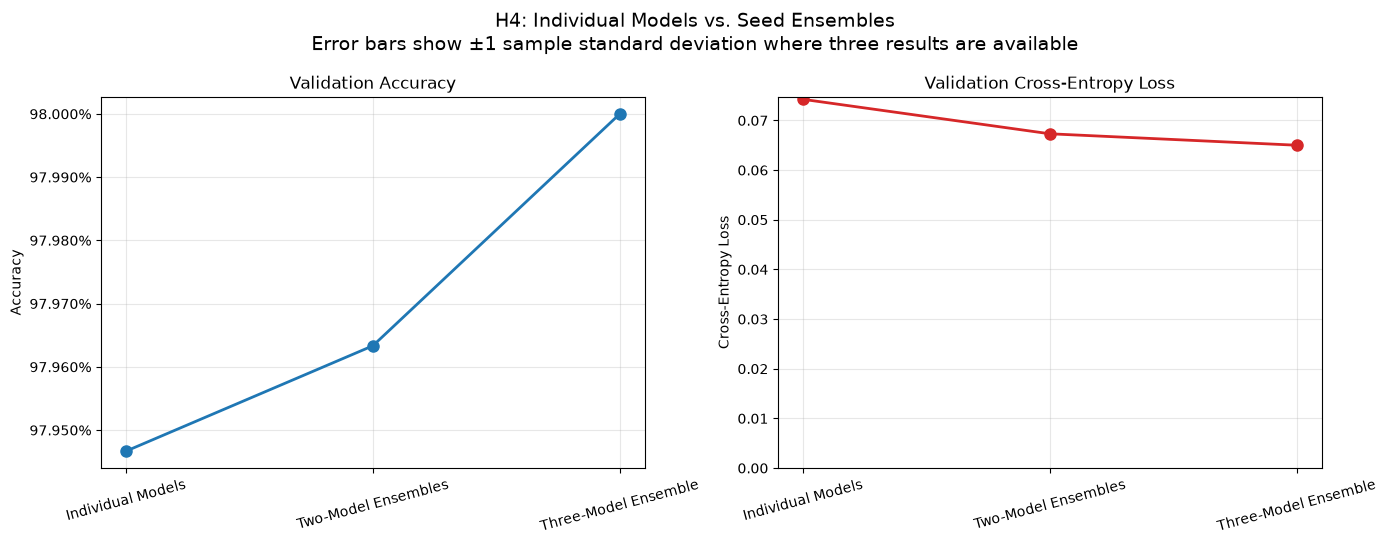

In [16]:
comparison_labels = (
    oh4_comparison_df[
        "condition"
    ].tolist()
)

comparison_positions = np.arange(
    len(comparison_labels)
)

accuracy_means = oh4_comparison_df[
    "accuracy_mean"
].to_numpy()

accuracy_stds = oh4_comparison_df[
    "accuracy_std"
].to_numpy()

loss_means = oh4_comparison_df[
    "loss_mean"
].to_numpy()

loss_stds = oh4_comparison_df[
    "loss_std"
].to_numpy()


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5)
)


axes[0].errorbar(
    comparison_positions,
    accuracy_means,
    # yerr=accuracy_stds,
    marker="o",
    markersize=8,
    linewidth=2,
    capsize=5
)

axes[0].set_title(
    "Validation Accuracy"
)

axes[0].set_ylabel("Accuracy")

axes[0].yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

axes[0].set_xticks(
    comparison_positions
)

axes[0].set_xticklabels(
    comparison_labels,
    rotation=15
)

axes[0].grid(alpha=0.3)


axes[1].errorbar(
    comparison_positions,
    loss_means,
    # yerr=loss_stds,
    marker="o",
    markersize=8,
    linewidth=2,
    capsize=5,
    color="tab:red"
)

axes[1].set_title(
    "Validation Cross-Entropy Loss"
)

axes[1].set_ylabel(
    "Cross-Entropy Loss"
)

axes[1].set_xticks(
    comparison_positions
)

axes[1].set_xticklabels(
    comparison_labels,
    rotation=15
)

axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.3)


fig.suptitle(
    "H4: Individual Models vs. Seed Ensembles\n"
    "Error bars show ±1 sample standard deviation "
    "where three results are available",
    fontsize=14
)

plt.tight_layout()


oh4_figure_png = (
    OH4_OUTPUT_DIR
    / "h4_individual_vs_ensemble.png"
)

oh4_figure_pdf = (
    OH4_OUTPUT_DIR
    / "h4_individual_vs_ensemble.pdf"
)


fig.savefig(
    oh4_figure_png,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    oh4_figure_pdf,
    bbox_inches="tight"
)


print("Saved:", oh4_figure_png)
print("Saved:", oh4_figure_pdf)

plt.show()
plt.close(fig)

In [17]:
individual_prediction_matrix = np.stack([
    oh4_individual_metrics[
        seed
    ]["predictions"]
    for seed in OH4_SEEDS
])


individual_correct_matrix = (
    individual_prediction_matrix
    == y_val[np.newaxis, :]
)


number_of_correct_individuals = np.sum(
    individual_correct_matrix,
    axis=0
)


full_ensemble_predictions = (
    oh4_full_metrics[
        "predictions"
    ]
)


ensemble_is_correct = (
    full_ensemble_predictions
    == y_val
)


ensemble_rescue_mask = (
    ensemble_is_correct
    & (number_of_correct_individuals < 3)
)


ensemble_rescue_indices = np.where(
    ensemble_rescue_mask
)[0]


print(
    "Examples where the ensemble is correct "
    "and at least one individual is wrong:",
    len(ensemble_rescue_indices)
)

Examples where the ensemble is correct and at least one individual is wrong: 86


Saved: output/hypotheses/h4_seed_ensemble/h4_ensemble_corrected_examples.png


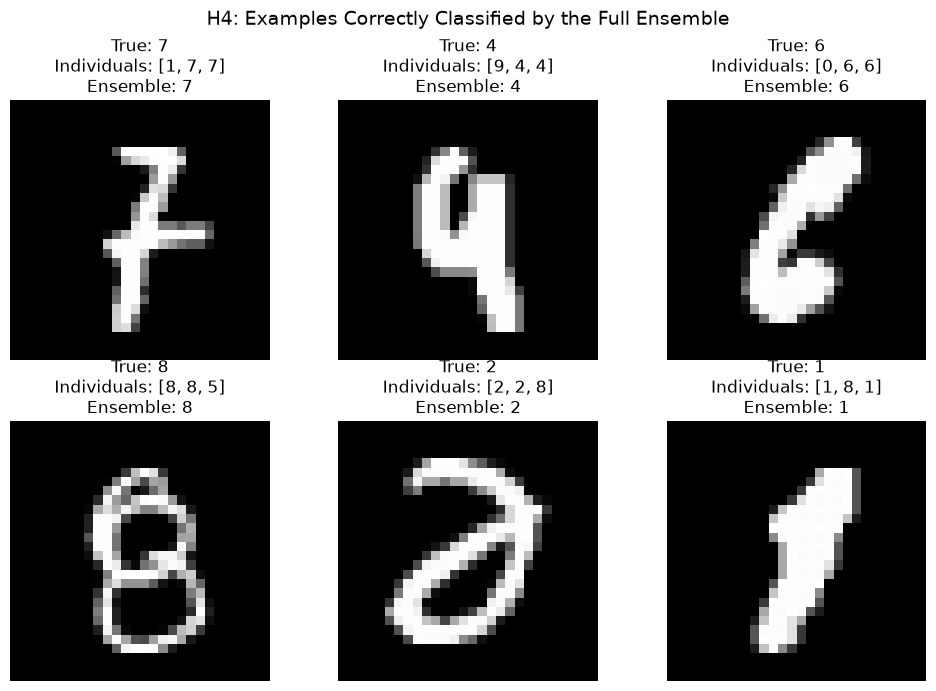

In [18]:
number_to_display = min(
    6,
    len(ensemble_rescue_indices)
)


if number_to_display > 0:

    display_indices = (
        ensemble_rescue_indices[
            :number_to_display
        ]
    )

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(10, 7)
    )

    axes = axes.ravel()

    for plot_index, example_index in enumerate(
        display_indices
    ):
        individual_predictions = (
            individual_prediction_matrix[
                :,
                example_index
            ]
        )

        axes[plot_index].imshow(
            X_val[
                example_index
            ].reshape(28, 28),
            cmap="gray"
        )

        axes[plot_index].set_title(
            f"True: {y_val[example_index]}\n"
            f"Individuals: "
            f"{individual_predictions.tolist()}\n"
            f"Ensemble: "
            f"{full_ensemble_predictions[example_index]}"
        )

        axes[plot_index].axis("off")

    for unused_index in range(
        number_to_display,
        len(axes)
    ):
        axes[unused_index].axis("off")

    fig.suptitle(
        "H4: Examples Correctly Classified "
        "by the Full Ensemble",
        fontsize=14
    )

    plt.tight_layout()

    oh4_examples_path = (
        OH4_OUTPUT_DIR
        / "h4_ensemble_corrected_examples.png"
    )

    fig.savefig(
        oh4_examples_path,
        dpi=300,
        bbox_inches="tight"
    )

    print("Saved:", oh4_examples_path)

    plt.show()
    plt.close(fig)

else:
    print(
        "No ensemble-rescued examples were found."
    )

In [19]:
individual_accuracy_mean = (
    oh4_individual_df[
        "accuracy"
    ].mean()
)

pair_accuracy_mean = (
    oh4_pairs_df[
        "accuracy"
    ].mean()
)

individual_loss_mean = (
    oh4_individual_df[
        "loss"
    ].mean()
)

pair_loss_mean = (
    oh4_pairs_df[
        "loss"
    ].mean()
)


pair_accuracy_change = (
    pair_accuracy_mean
    - individual_accuracy_mean
)

pair_loss_reduction = (
    individual_loss_mean
    - pair_loss_mean
)


print(
    "Mean individual accuracy:",
    f"{100 * individual_accuracy_mean:.2f}%"
)

print(
    "Mean two-model ensemble accuracy:",
    f"{100 * pair_accuracy_mean:.2f}%"
)

print(
    "Two-model accuracy change:",
    f"{100 * pair_accuracy_change:+.2f} "
    "percentage points"
)

print(
    "Mean individual loss:",
    f"{individual_loss_mean:.4f}"
)

print(
    "Mean two-model ensemble loss:",
    f"{pair_loss_mean:.4f}"
)

print(
    "Two-model loss reduction:",
    f"{pair_loss_reduction:+.4f}"
)

print(
    "\nFull ensemble accuracy:",
    f"{100 * oh4_full_metrics['accuracy']:.2f}%"
)

print(
    "Full ensemble loss:",
    f"{oh4_full_metrics['loss']:.4f}"
)

print(
    "Full ensemble accuracy change "
    "from mean individual:",
    f"{100 * oh4_full_accuracy_improvement:+.2f} "
    "percentage points"
)

print(
    "Full ensemble loss reduction "
    "from mean individual:",
    f"{oh4_full_loss_reduction:+.4f}"
)

Mean individual accuracy: 97.95%
Mean two-model ensemble accuracy: 97.96%
Two-model accuracy change: +0.02 percentage points
Mean individual loss: 0.0743
Mean two-model ensemble loss: 0.0673
Two-model loss reduction: +0.0069

Full ensemble accuracy: 98.00%
Full ensemble loss: 0.0650
Full ensemble accuracy change from mean individual: +0.05 percentage points
Full ensemble loss reduction from mean individual: +0.0092


In [20]:
oh4_results_df.to_csv(
    OH4_OUTPUT_DIR
    / "h4_all_model_results.csv",
    index=False
)

oh4_results_display_df.to_csv(
    OH4_OUTPUT_DIR
    / "h4_all_model_results_formatted.csv",
    index=False
)

oh4_comparison_df.to_csv(
    OH4_OUTPUT_DIR
    / "h4_group_comparison_numeric.csv",
    index=False
)

oh4_comparison_display_df.to_csv(
    OH4_OUTPUT_DIR
    / "h4_group_comparison_formatted.csv",
    index=False
)


oh4_checkpoint_df.to_csv(
    OH4_OUTPUT_DIR
    / "h4_model_checkpoints.csv",
    index=False
)


print("Saved H4 files:")

for saved_file in sorted(
    OH4_OUTPUT_DIR.iterdir()
):
    print("-", saved_file)

Saved H4 files:
- output/hypotheses/h4_seed_ensemble/h4_all_model_results.csv
- output/hypotheses/h4_seed_ensemble/h4_all_model_results_formatted.csv
- output/hypotheses/h4_seed_ensemble/h4_ensemble_corrected_examples.png
- output/hypotheses/h4_seed_ensemble/h4_group_comparison_formatted.csv
- output/hypotheses/h4_seed_ensemble/h4_group_comparison_numeric.csv
- output/hypotheses/h4_seed_ensemble/h4_individual_vs_ensemble.pdf
- output/hypotheses/h4_seed_ensemble/h4_individual_vs_ensemble.png
- output/hypotheses/h4_seed_ensemble/h4_model_checkpoints.csv
